In [ ]:
from dotenv import load_dotenv, find_dotenv
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv(find_dotenv())

In [9]:
from langchain_groq import ChatGroq
model = ChatGroq(model="llama-3.1-8b-instant")

In [10]:
from langgraph.graph import START, END, StateGraph

### State

In [22]:
from typing import TypedDict


### Creation du graphe

In [23]:
builder =

In [ ]:
### creation des noeuds
#state["messages"] = state["messages"] + "Hello World"



### ajout des edges

### Compilation du graphe

In [ ]:
graph = builder.compile()
graph

In [ ]:
#execution du workflow


In [42]:
from typing import Annotated
from langgraph.graph.message import add_messages, MessagesState

#Creation d'un state


In [ ]:
# the graph









res = graph.invoke({"messages": "je suis youssef saadi professeur d'informatique et je souhaite des informations sur le langage python"})
res

In [ ]:
res = graph.invoke({"messages": "qui suis je ?? et c'est quoi mon nom?"})
res

### Ajout de mémoire a notre agent

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

graph = builder.compile(checkpointer=MemorySaver())

thread1 = {"configurable" : {"thread_id" : "1"}}

res = graph.invoke({"messages": "je suis youssef saadi professeur d'informatique et je souhaite des informations sur le langage python  "}, thread1)
print(res)

In [ ]:
res = graph.invoke({"messages": "qui suis je ?? et c'est quoi mon nom?"}, thread1)
print(res)

In [ ]:
for msg in graph.stream({"messages": "qui suis je ?? et c'est quoi mon nom?"}, thread1):
    print(msg)

### chainage

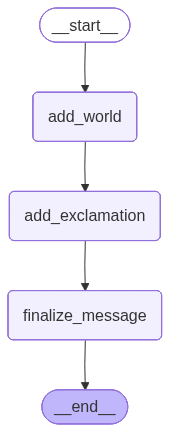

In [38]:
#premier noeud ajoute le mot "world" à l'état global representé par le
###Input and Output Schemas
class OverallState(TypedDict):
    partial_message: str
    user_input:str
    message_output:str

class PrivateState(TypedDict):
    private_message: str
class OutputState(TypedDict):
    message_output: str
class InputState(TypedDict):
    user_input: str

def add_world(state : InputState) -> OverallState:
    partial_message = state['user_input'] +  " World"
    return {"partial_message": partial_message, "user_input" : state['user_input'], "private_message" : ""}

def add_exclamation(state : OverallState) -> PrivateState:
    private_message = state['partial_message'] + "!!"
    state['private_message'] = private_message
    return {"private_message": private_message}

def finalize_message(state : PrivateState) -> OutputState:
    output_message =  state['private_message'] + " you are welcome!"
    return {"message_output": output_message}

builder = StateGraph(OverallState)

builder.add_node("add_world", add_world)
builder.add_node("add_exclamation", add_exclamation)
builder.add_node("finalize_message", finalize_message)

builder.add_edge(START, "add_world")
builder.add_edge("add_world", "add_exclamation")
builder.add_edge("add_exclamation", "finalize_message")
builder.add_edge("finalize_message", END)

graph = builder.compile()
graph


In [39]:
result = graph.invoke({"user_input": "Hello  "})
result

{'partial_message': 'Hello   World',
 'user_input': 'Hello  ',
 'message_output': 'Hello   World!! you are welcome!'}

In [ ]:
#Todo : #One LLM call to generate a SQL query from the natural language query and Another LLM call to write an explanation of the query appropriate for a nontechnical user

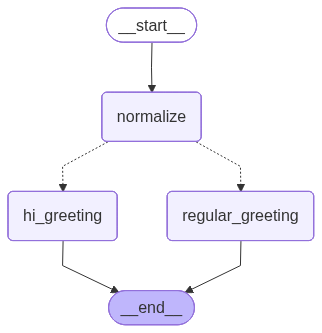

In [40]:
### Routers
### Conditional Greeting Agent
class GreetingState(TypedDict):
    greeting: str

def normalize_greeting_node(state: GreetingState) -> GreetingState:
    greeting = state['greeting'].lower()
    return {"greeting": greeting}
def hi_greeting_node(state: GreetingState) -> GreetingState:
    state['greeting'] = "Hi there, " + state['greeting']
    return state
def regular_greeting_node(state: GreetingState) -> GreetingState:
    state['greeting'] = "Hello , " + state['greeting']
    return state

def choose_greeting_node(state: GreetingState) -> str:
    return "hi_greeting" if "hi" in state['greeting'] else "regular_greeting"

builder = StateGraph(GreetingState)
builder.add_node("normalize", normalize_greeting_node)
builder.add_node("hi_greeting", hi_greeting_node)
builder.add_node("regular_greeting", regular_greeting_node)

#Todo

In [41]:
result = graph.invoke({"greeting": "HI THERe!"})
print(result) # Expected Output: {'greeting': 'Hi there, hi there!'}
# Test with a greeting not containing "Hi"
result = graph.invoke({"greeting": "Good morning!"})
print(result) # Expected Output: {'greeting': 'Hello, good morning!'}

{'greeting': 'Hi there, hi there!'}
{'greeting': 'Hello , good morning!'}


### tools

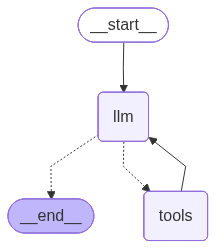

In [43]:
### Tools
from langchain_core.tools import tool
# ============================================
# 1. OUTIL
# ============================================
@tool
def get_weather(location: str) -> str:
    """Fetch the current weather for a specific location."""
    weather_data = {
        "San Francisco": "It's 60 degrees and foggy.",
        "New York": "It's 90 degrees and sunny.",
        "London": "It's 70 degrees and cloudy."
    }
    return weather_data.get(location, "Weather information is unavailable for this location.")

# ============================================
# 2. MODÈLE
# ============================================


# ============================================
# 3. NŒUDS DU GRAPHE
# ============================================

def llm_call(state: MessagesState):
    """Nœud LLM : Le modèle reçoit TOUS les messages et décide."""
    #Todo
    return {"messages": [response]}

# ============================================
# 4. GRAPHE
# ============================================
from langgraph.prebuilt import ToolNode, tools_condition
workflow = StateGraph(MessagesState)
# Ajout des nœuds
#ToDo
# Flux
workflow.add_edge(START, "llm")
# Arête conditionnelle : si tool_calls → tools, sinon → END
workflow.add_conditional_edges(
    "llm",
    tools_condition,
    {
        "tools": "tools",
        END: END
    }
)

# Après l'outil, retour au LLM pour interpréter le résultat
#Todo
#compilation du graph
#Todo

In [ ]:
# ============================================
# 5. TEST
# ============================================
from langchain_core.messages import HumanMessage
input_message = {"messages": [HumanMessage(content="what is the weather in New York")]}

